# Credit approval project UCI 'crx.data'

This notebook covers the full project pipeline, numbered to match the assignment:

- **2) Exploratory data analysis (EDA)**
- **3) Preprocessing, feature selection and engineering**
- **4) Model creation and evaluation**


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 100


## 2) Exploratory data analysis (EDA)


## 2.1 Load the data

The 16 columns are anonymized ('A1'–'A16'); 'A16' (renamed 'target') is the approval decision: '+' = approved, '-' = denied.


In [3]:
col_names = [f"A{i}" for i in range(1, 17)]
col_names[-1] = "target"

df = pd.read_csv("crx.data", header=None, names=col_names)
df.head()


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,target
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,00202,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,00043,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,00280,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,00100,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,00120,0,+


## 2.2 Clean missing-value markers and fix dtypes

This dataset encodes missing values as the string "?" rather than a blank/NaN. 'A2' (age) and 'A14' are numeric but get read as text because of these markers, so we convert them after replacing "?".


In [4]:
df.replace("?", np.nan, inplace=True)

for col in ["A2", "A14"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

numeric_cols = ["A2", "A3", "A8", "A11", "A14", "A15"]
categorical_cols = [c for c in col_names if c not in numeric_cols + ["target"]]

df.dtypes


A1         object
A2        float64
A3        float64
A4         object
A5         object
A6         object
A7         object
A8        float64
A9         object
A10        object
A11         int64
A12        object
A13        object
A14       float64
A15         int64
target     object
dtype: object

### 2.3 Missing values


In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Missing values per column:")
print(missing)
print()
print("Total rows with at least one missing value:", df.isnull().any(axis=1).sum())


Missing values per column:
A14    13
A2     12
A1     12
A7      9
A6      9
A4      6
A5      6
dtype: int64

Total rows with at least one missing value: 37


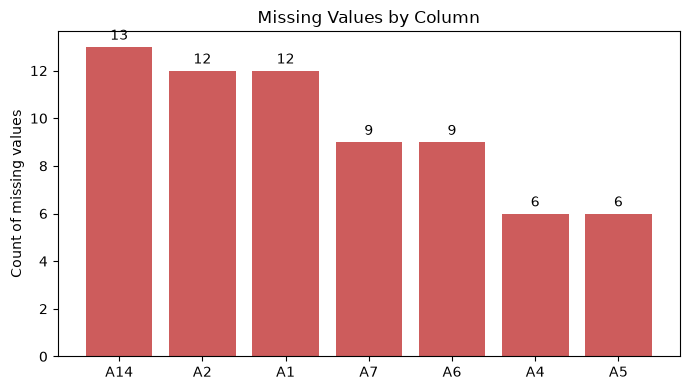

In [6]:
fig, ax = plt.subplots(figsize=(7,4))
ax.bar(missing.index, missing.values, color="indianred")
ax.set_title("Missing Values by Column")
ax.set_ylabel("Count of missing values")
for i, v in enumerate(missing.values):
    ax.text(i, v+0.3, str(v), ha="center")
plt.tight_layout()
plt.show()


**Findings:** 7 of the 16 columns have missing values, but the counts are small (6-13 rows out of 690, all under 2% each). Only **37 of 690 rows (~5.4%)** have any missing value at all. This is minor enough that rows could either be dropped or imputed (e.g. median for numeric, mode for categorical) without much data loss.

### 2.4 Numeric feature distributions (visualizations)


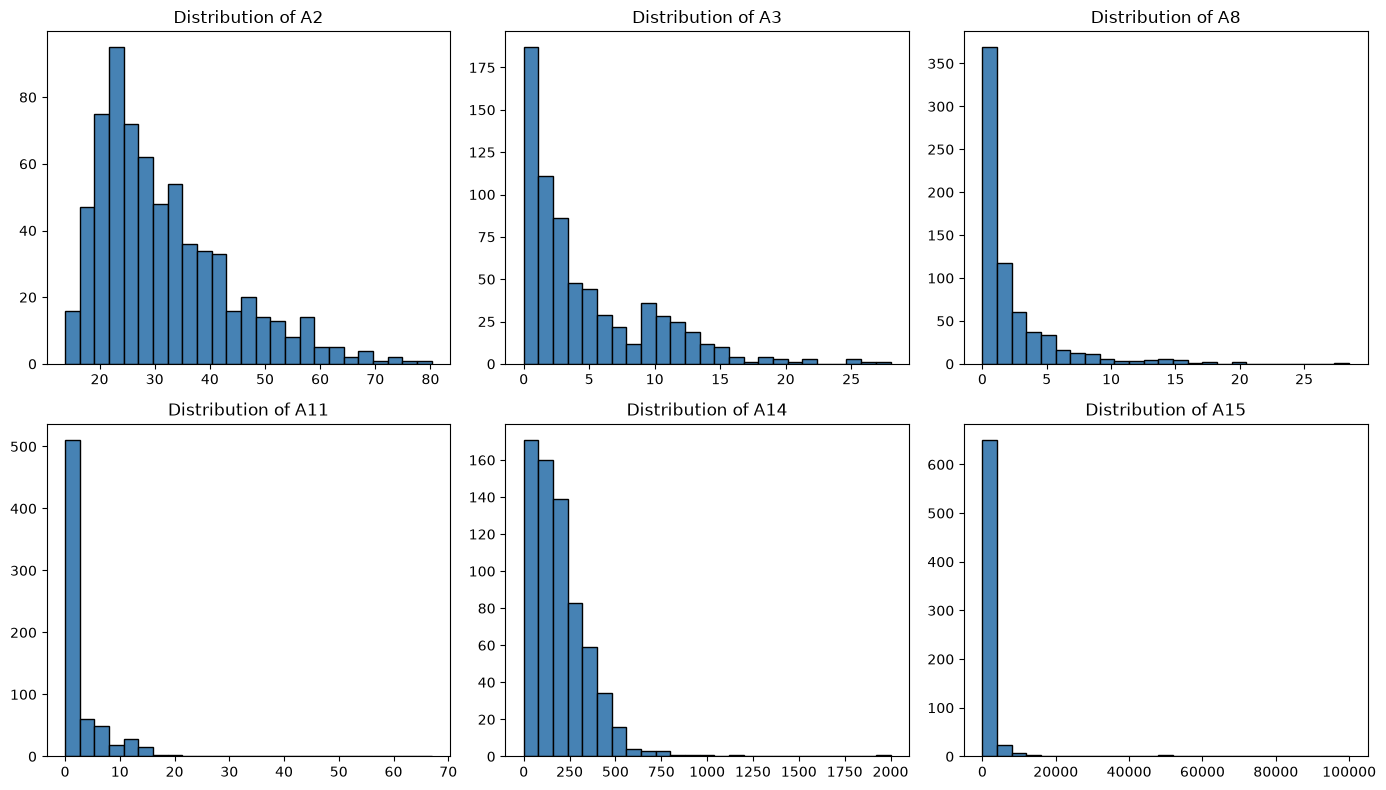

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(14,8))
for ax, col in zip(axes.flat, numeric_cols):
    ax.hist(df[col].dropna(), bins=25, color="steelblue", edgecolor="black")
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()


**Findings:** All six numeric columns ('A2', 'A3', 'A8', 'A11', 'A14', 'A15') are strongly right-skewed-most values cluster near zero/low values with a long tail toward large ones. 'A15' in particular has an extreme tail (max ~100,000 while the median is 5), suggesting a monetary field with a few very large accounts. This skew is consistent with the outliers found in Section 6.

### 2.5 Categorical feature distributions (visualizations)


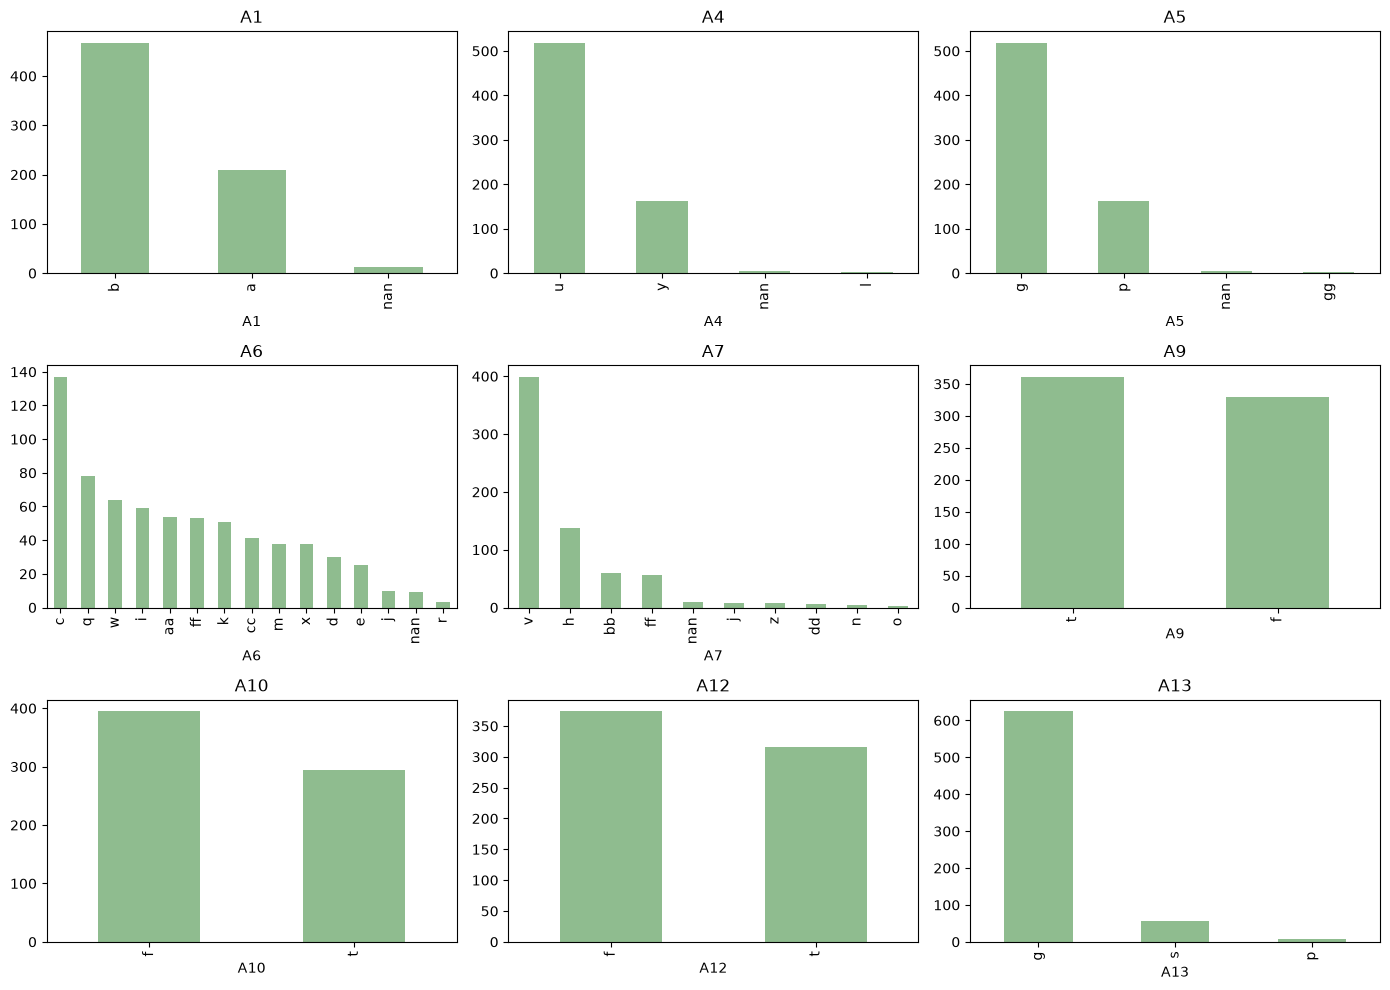

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(14,10))
for ax, col in zip(axes.flat, categorical_cols):
    df[col].value_counts(dropna=False).plot(kind="bar", ax=ax, color="darkseagreen")
    ax.set_title(col)
for ax in axes.flat[len(categorical_cols):]:
    ax.axis("off")
plt.tight_layout()
plt.show()


**Findings:** Several categorical columns are highly imbalanced (e.g. 'A9', 'A10', 'A12', 'A13' each have one dominant category), while others like 'A6' and 'A7' have many low-frequency levels. This imbalance is worth accounting for later, e.g. grouping rare categories before modeling.

### 2.6 Target class balance (visualization)


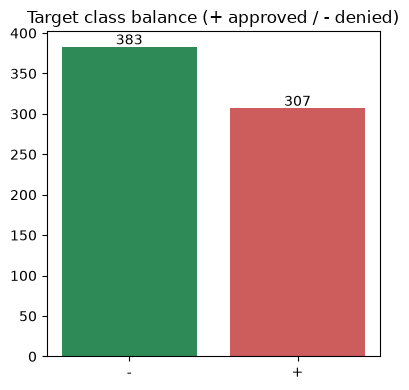

In [9]:
counts = df["target"].value_counts()
fig, ax = plt.subplots(figsize=(4,4))
ax.bar(counts.index, counts.values, color=["seagreen","indianred"])
ax.set_title("Target class balance (+ approved / - denied)")
for i, v in enumerate(counts.values):
    ax.text(i, v+3, str(v), ha="center")
plt.tight_layout()
plt.show()


**Findings:** The classes are reasonably balanced, roughly 44% approved vs 56% denied, so no heavy resampling is needed for later modeling.

### 2.7 Correlation between numeric features (visualization)


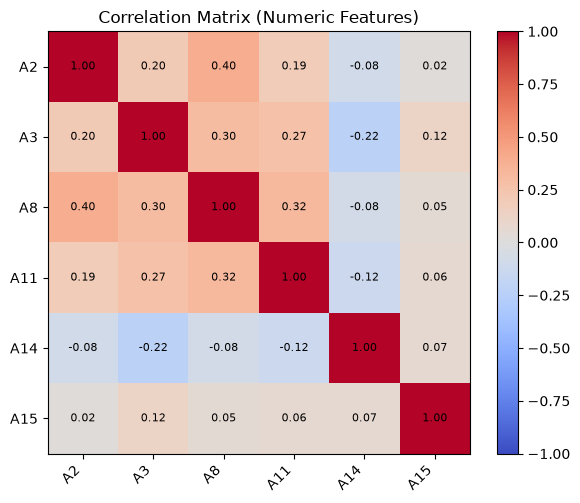

In [10]:
corr = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im)
ax.set_title("Correlation Matrix (Numeric Features)")
plt.tight_layout()
plt.show()


**Findings:** Correlations among the numeric features are generally weak (mostly under 0.3), meaning multicollinearity isn't a major concern here. 'A8' and 'A11' show the strongest relationship of the group, but even that is modest.

### 2.8 Outlier detection

#### Boxplots


C:\Users\rimwe\AppData\Local\Temp\ipykernel_27712\778306953.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[col].dropna(), vert=True)
C:\Users\rimwe\AppData\Local\Temp\ipykernel_27712\778306953.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[col].dropna(), vert=True)
C:\Users\rimwe\AppData\Local\Temp\ipykernel_27712\778306953.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[col].dropna(), vert=True)
C:\Users\rimwe\AppData\Local\Temp\ipykernel_27712\778306953.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'hori

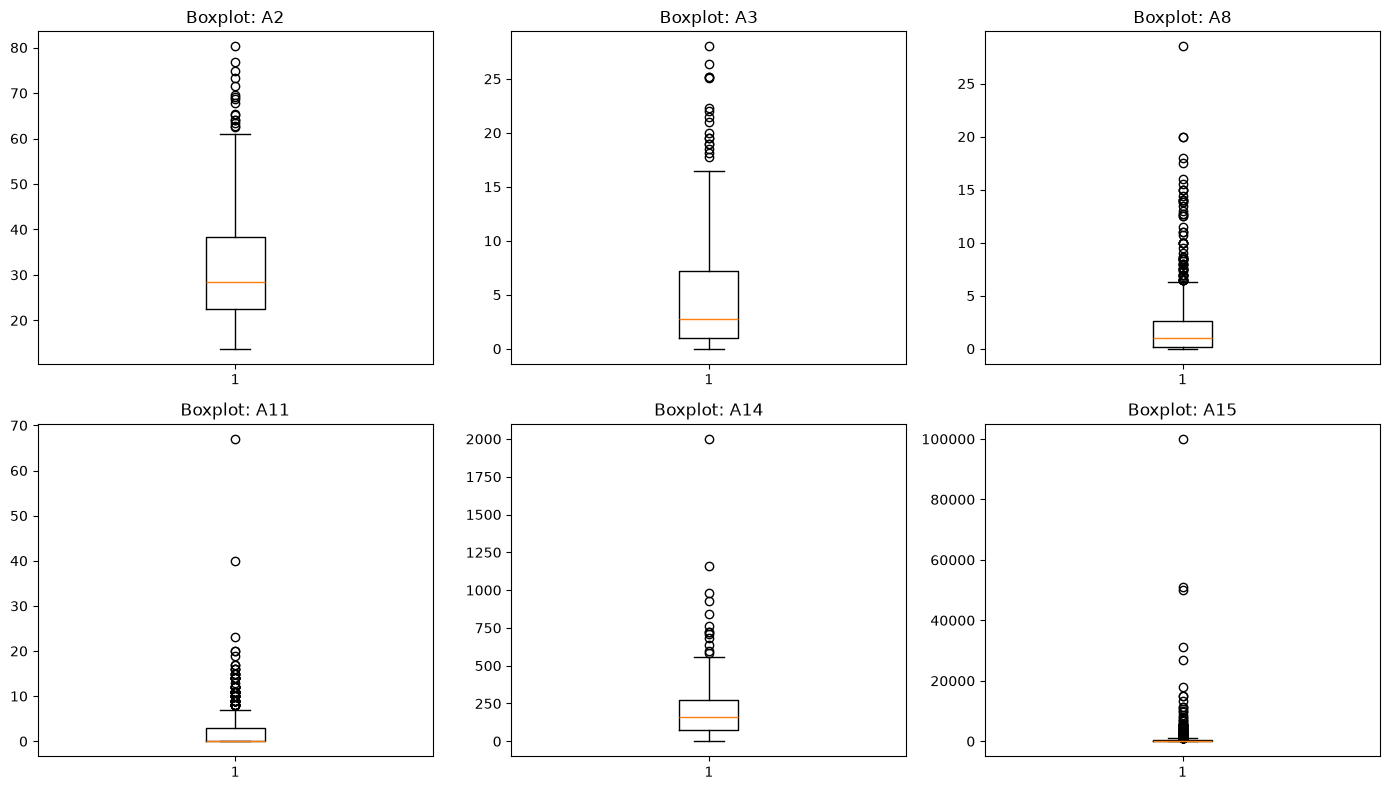

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(14,8))
for ax, col in zip(axes.flat, numeric_cols):
    ax.boxplot(df[col].dropna(), vert=True)
    ax.set_title(f"Boxplot: {col}")
plt.tight_layout()
plt.show()


#### IQR-based outlier counts


In [15]:
outlier_summary = {}
for col in numeric_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    outlier_summary[col] = n_out
    print(f"{col}: {n_out} outliers  (bounds: [{lower:.2f}, {upper:.2f}])")


A2: 16 outliers  (bounds: [-0.84, 61.67])
A3: 17 outliers  (bounds: [-8.31, 16.52])
A8: 63 outliers  (bounds: [-3.52, 6.31])
A11: 79 outliers  (bounds: [-4.50, 7.50])
A14: 13 outliers  (bounds: [-226.50, 577.50])
A15: 113 outliers  (bounds: [-593.25, 988.75])


**Findings:** Every numeric column has outliers by the IQR rule, but they're concentrated most heavily in 'A15' (113 rows, ~16% of the data) and 'A11' (79 rows, ~11%), consistent with their skewed distributions in Section 4. These aren't necessarily data errors; for financial fields like these, a small number of legitimately high-value accounts is expected. Still, models sensitive to scale (e.g. linear/logistic regression, KNN) would benefit from a log transform or robust scaling on 'A15', 'A11', and 'A8' before training.

### 2.9 EDA Summary

- **Missing values:** 7 columns affected, all minor (≤13 rows each); only 5.4% of rows have any missing value. '"?"' is the missing-value sentinel, not blank/NaN.
- **Distributions:** All numeric features are right-skewed; several categorical features are dominated by one category.
- **Target balance:** Reasonably balanced (~44% / 56%), so no resampling needed.
- **Correlations:** Weak among numeric features, low multicollinearity risk.
- **Outliers:** Present in all numeric columns, most heavily in 'A15' and 'A11'. Consider log-transforming or robust-scaling these before modeling, and decide on an imputation strategy for the missing values (median/mode are reasonable given the small proportion missing).

## 3) Preprocessing, Feature Selection and Engineering, and 4) Model Creation and Evaluation

This section makes the data ready for machine learning models, then builds and evaluates classification models as required by the assignment.


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

RANDOM_STATE = 42


### 3.0 Load data and identify column groups

Columns are anonymized ('A1'-'A16'); 'A16' (renamed 'target') is the class label. From the EDA:
- **Numeric**: A2, A3, A8, A11, A14, A15
- **Binary categorical** (2 levels): A1, A9, A10, A12
- **Nominal categorical** (3+ levels): A4, A5, A6, A7, A13


In [20]:
col_names = [f"A{i}" for i in range(1, 17)]
col_names[-1] = "target"
df = pd.read_csv("crx.data", header=None, names=col_names)
df = df.replace("?", np.nan)
for c in ["A2", "A14"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

num_cols = ["A2", "A3", "A8", "A11", "A14", "A15"]
binary_cols = ["A1", "A9", "A10", "A12"]
nominal_cols = ["A4", "A5", "A6", "A7", "A13"]

X = df[num_cols + binary_cols + nominal_cols].copy()
y = df["target"].map({"+": 1, "-": 0}).values
print(X.shape, y.shape)


(690, 15) (690,)


### 3.0.1 Train/test split

Split before any imputation, capping, encoding, or scaling, all preprocessing statistics (medians, IQR bounds, scaler mean/std, encoder categories) are learned **only from the training set** and then applied to the test set, to avoid data leakage. Stratified on the target to preserve class balance.


In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train class balance (0=denied,1=approved):", np.bincount(y_train))
print("Test class balance:", np.bincount(y_test))


Train shape: (552, 15) Test shape: (138, 15)
Train class balance (0=denied,1=approved): [306 246]
Test class balance: [77 61]


## 3a) Handle missing values and outliers

- **Missing values**: numeric columns imputed with the **median** (robust to the skew/outliers seen in EDA); categorical columns imputed with the **most frequent category**.
- **Outliers**: EDA found outliers (via IQR) in every numeric column, heaviest in A15 and A11. Rather than dropping rows (which would lose ~16% of data for A15 alone), outliers are **capped (winsorized)** to the '[Q1 - 1.5*IQR, Q3 + 1.5*IQR]' bounds. Bounds are computed from the **training set only** and reused on the test set.


In [22]:
class IQRCapper(BaseEstimator, TransformerMixin):
    """Winsorize numeric features to the 1.5*IQR bounds, fit on training data only."""
    def __init__(self, factor=1.5):
        self.factor = factor
    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        Q1 = np.nanpercentile(X, 25, axis=0)
        Q3 = np.nanpercentile(X, 75, axis=0)
        IQR = Q3 - Q1
        self.lower_ = Q1 - self.factor * IQR
        self.upper_ = Q3 + self.factor * IQR
        return self
    def transform(self, X):
        X = np.asarray(X, dtype=float).copy()
        return np.clip(X, self.lower_, self.upper_)


## 3b) Label encoding and data scaling

- **Binary columns** (A1, A9, A10, A12 exactly 2 levels each): 'OrdinalEncoder', which is equivalent to label encoding for a 2-level feature (0/1).
- **Nominal columns** (A4, A5, A6, A7, A13, 3+ unlabeled levels): 'OneHotEncoder'. Label encoding these would impose a false numeric order on unordered categories (e.g. A6 has 14 levels), which would mislead distance-based or linear models one-hot avoids that.
- **Numeric columns**: 'StandardScaler' after imputation and capping, important for both Logistic Regression (regularization is scale-sensitive) and the neural network (gradient-based optimizers converge much better on standardized inputs).

All of this is wrapped in a single 'ColumnTransformer' so it can be reused identically inside every model pipeline and every cross-validation fold (fit only on each fold's training portion).


In [23]:
numeric_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("cap", IQRCapper(factor=1.5)),
    ("scale", StandardScaler()),
])

binary_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", OrdinalEncoder()),
])

nominal_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("bin", binary_pipeline, binary_cols),
    ("nom", nominal_pipeline, nominal_cols),
])


## 4a) Classification-based model, with two performance metrics (justified)

**Model: Logistic Regression** a strong, interpretable linear benchmark that's standard for binary approval/decline decisions and trains fast, giving a fair reference point for the neural network in 4b/4c.

**Metrics chosen: Accuracy and F1-score**, justified below:
- **Accuracy** is easy to interpret and reasonable here since the classes are only mildly imbalanced (roughly 56%/44%).
- **F1-score** (harmonic mean of precision and recall) matters because in credit approval, false approvals (giving credit to someone who should be denied) and false denials (turning away a creditworthy applicant) are **both costly but in different ways** F1 penalizes a model that only does well on one of precision/recall, which plain accuracy can hide.


In [24]:
baseline_pipe = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
baseline_pipe.fit(X_train, y_train)
y_pred_base = baseline_pipe.predict(X_test)
y_proba_base = baseline_pipe.predict_proba(X_test)[:, 1]

acc_base = accuracy_score(y_test, y_pred_base)
f1_base = f1_score(y_test, y_pred_base)
auc_base = roc_auc_score(y_test, y_proba_base)

print(f"Accuracy: {acc_base:.4f}")
print(f"F1-score: {f1_base:.4f}")
print(f"ROC-AUC : {auc_base:.4f}  (reported for reference)")
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_base))


Accuracy: 0.8551
F1-score: 0.8333
ROC-AUC : 0.9591  (reported for reference)
Confusion matrix:
 [[68  9]
 [11 50]]


## 4b) Neural network model (multi-layer), evaluated with 10-fold cross-validation

A **multi-layer** 'MLPClassifier' (two hidden layers: 64 then 32 units, ReLU activation, Adam optimizer) is evaluated with **10-fold stratified cross-validation** on the training set. The same 'preprocessor' is refit inside every fold (via the pipeline) so there is no leakage between folds.

Same metrics as 4a (**Accuracy, F1-score**) are used, for a like-for-like comparison with the baseline.


In [25]:
mlp_pipe = Pipeline([
    ("prep", preprocessor),
    ("clf", MLPClassifier(hidden_layer_sizes=(64, 32), activation="relu",
                           solver="adam", max_iter=2000, random_state=RANDOM_STATE)),
])

cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
cv_results = cross_validate(
    mlp_pipe, X_train, y_train, cv=cv10,
    scoring=["accuracy", "f1"], return_train_score=False
)

print(f"10-fold CV Accuracy: {cv_results['test_accuracy'].mean():.4f} +/- {cv_results['test_accuracy'].std():.4f}")
print(f"10-fold CV F1-score: {cv_results['test_f1'].mean():.4f} +/- {cv_results['test_f1'].std():.4f}")

# Fit on the full training set once, to compare against the held-out test set later
mlp_pipe.fit(X_train, y_train)
y_pred_mlp = mlp_pipe.predict(X_test)
print(f"\nUntuned MLP on held-out test -> Accuracy: {accuracy_score(y_test, y_pred_mlp):.4f}, "
      f"F1: {f1_score(y_test, y_pred_mlp):.4f}")


10-fold CV Accuracy: 0.8259 +/- 0.0451
10-fold CV F1-score: 0.7973 +/- 0.0609

Untuned MLP on held-out test -> Accuracy: 0.8116, F1: 0.7797


**Findings:** the untuned MLP performs *slightly worse* than the Logistic Regression baseline on both metrics not unusual, since neural networks have more parameters and hyperparameters (layer sizes, learning rate, activation, optimizer) that typically need tuning to be competitive on a relatively small dataset (552 training rows). That tuning is done next.


## 4c) Hyperparameter tuning with GridSearchCV (10-fold cross-validation)

Search space includes **4 hyperparameters** (at least 3 required): 'activation', 'learning_rate_init', 'solver' (optimizer), and 'hidden_layer_sizes'. Scored on **F1-score**, using the same 10-fold stratified CV, and refit on the full training set with the best combination found.


In [26]:
param_grid = {
    "clf__hidden_layer_sizes": [(32,), (64, 32)],
    "clf__activation": ["relu", "tanh"],
    "clf__learning_rate_init": [0.001, 0.01],
    "clf__solver": ["adam", "sgd"],
}

grid = GridSearchCV(
    mlp_pipe, param_grid=param_grid, cv=cv10,
    scoring="f1", n_jobs=-1, refit=True
)
grid.fit(X_train, y_train)

print("Best hyperparameters:", grid.best_params_)
print(f"Best 10-fold CV F1-score: {grid.best_score_:.4f}")

best_model = grid.best_estimator_
y_pred_tuned = best_model.predict(X_test)
y_proba_tuned = best_model.predict_proba(X_test)[:, 1]

acc_tuned = accuracy_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)
auc_tuned = roc_auc_score(y_test, y_proba_tuned)
print(f"\nTuned MLP on held-out test -> Accuracy: {acc_tuned:.4f}, F1: {f1_tuned:.4f}, ROC-AUC: {auc_tuned:.4f}")


Best hyperparameters: {'clf__activation': 'tanh', 'clf__hidden_layer_sizes': (64, 32), 'clf__learning_rate_init': 0.001, 'clf__solver': 'sgd'}
Best 10-fold CV F1-score: 0.8263

Tuned MLP on held-out test -> Accuracy: 0.8841, F1: 0.8621, ROC-AUC: 0.9661


**Findings:** Grid search selected 'tanh' activation, two hidden layers (64 to 32), a smaller learning rate (0.001), and plain SGD over Adam. Tuning lifted 10-fold CV F1 from ~0.797 to 0.826, and the tuned model now clearly **outperforms the untuned MLP** on the held-out test set.


## 4d) Compare the tuned model (4c) against the model in 4a

Both models are evaluated on the same held-out test set for a fair comparison.


In [27]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression (4a)", "Tuned MLP (4c)"],
    "Accuracy": [acc_base, acc_tuned],
    "F1-score": [f1_base, f1_tuned],
})
print(comparison.to_string(index=False))


                   Model  Accuracy  F1-score
Logistic Regression (4a)  0.855072  0.833333
          Tuned MLP (4c)  0.884058  0.862069


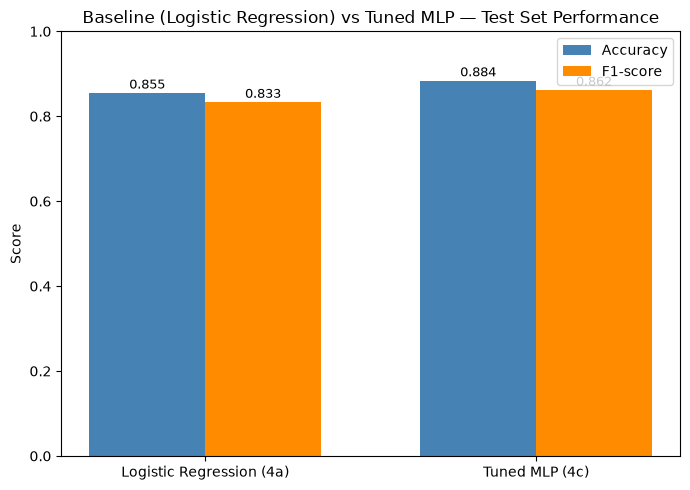

In [28]:
fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(2)
width = 0.35
ax.bar(x - width/2, comparison["Accuracy"], width, label="Accuracy", color="steelblue")
ax.bar(x + width/2, comparison["F1-score"], width, label="F1-score", color="darkorange")
ax.set_xticks(x)
ax.set_xticklabels(comparison["Model"])
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Baseline (Logistic Regression) vs Tuned MLP — Test Set Performance")
for i, v in enumerate(comparison["Accuracy"]):
    ax.text(i - width/2, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)
for i, v in enumerate(comparison["F1-score"]):
    ax.text(i + width/2, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)
ax.legend()
plt.tight_layout()
plt.show()


## Overall Summary

- **Preprocessing:** missing values imputed (median/mode), outliers capped via IQR winsorization (fit on train only), binary features ordinal-encoded, nominal features one-hot encoded, numeric features standardized, all inside a single reusable 'ColumnTransformer'.
- **4a Baseline (Logistic Regression):** Accuracy 0.855, F1 0.833 on the held-out test set.
- **4b Neural network (untuned MLP, 10-fold CV):** Accuracy 0.826 ± 0.045, F1 0.797 ± 0.061, slightly below the baseline before tuning.
- **4c Hyperparameter tuning (GridSearchCV, 10-fold CV):** best combo = 'tanh' activation, hidden layers (64, 32), learning rate 0.001, SGD solver to CV F1 0.826; on the test set, Accuracy 0.884, F1 0.862.
- **4d Comparison:** the tuned MLP **outperforms** the Logistic Regression baseline on both Accuracy (+0.029) and F1 (+0.029) on the same held-out test set, showing that hyperparameter tuning meaningfully closed (and reversed) the initial gap between the neural network and the simpler linear baseline.
